# Julián Serrano Chacón
# Mika Rodríguez Castro
  
# Práctica 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import time # para medir tiempos de ejecución
import soundfile as sf     
from ipywidgets import interact
import sys
import random as rnd

# graficos en el notebook
%matplotlib inline

SRATE = 48000 # Sample rate, para todo el notebook

#### Ejercicio 1 (Evaluable)

Modificar el reproductor con control de volumen visto en clase (con slider de IpyWidgets) para que permita ajustar el volumen de cada canal por separado, a través de dos variables volL y volR (volumen del canal izquierdo y derecho).  
Si la muestra de entrada es mono, debe lanzarse una excepción e interrumpir la ejecución.  
Dado un chunk de audio estéreo almacenado en un array de NumPy bloque, el canal izquierdo puede obtenerse con bloque[:,0] y el derecho con bloque[:,1]

In [ ]:
#* Ej1
CHUNK = 2048
data, SRATE = sf.read('media/ex1.wav',dtype=np.float32)

#* si el audio es mono no se reproduce
try:
    if (len(data.shape)==1): 
        raise Exception("Mono not supported")
    
except Exception as e:
    print(e.args[0])
    sys.exit()
    

print(f"SRATE: {SRATE}   Format: {data.dtype}   Channels: {len(data.shape)}    Len: {data.shape[0]}")

#* volumen Izquierdo y volumen derecho
volL = 0.5
volR = 0.5

# contador de frames, global
current_frame = 0
def callback(outdata, frames, time, status):
    global current_frame       # para actualizarlo en cada callBack
    if status: print(status)

    # ojo, este print es muy lento... puede provocar underruns
    #print(f"\rNum Bloque: {current_frame//CHUNK}  frame: {current_frame}", end='') 

    # escribimos los samples correspondientes en el outdata que viene dado
    bloque = data[current_frame : current_frame+CHUNK]

    # * En vez de modificar el volumen en todos los canales directamente usando la instruccion anterior,
    # * se modifica cada uno de los canales por separado usando sus respectivos volumenes
    bloque[:,0] *= volL
    bloque[:,1] *= volR
        
    chunksize = bloque.shape[0]

    outdata[:chunksize] = bloque       
    
    if chunksize < frames: # ha terminado?
        print('fin')
        outdata[chunksize:] = 0 # rellenamos con 0's el resto de outdata
        raise sd.CallbackStop()

    # actualizamos frame con los frames procesados    
    current_frame += chunksize


# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, channels=len(data.shape),
    callback=callback, blocksize=CHUNK)
stream.start()


# controles de reproducción: volumen y parada

# * Hacemos un slider para volumen izquierdo y derecho

def LvolCtrl(Lv):
    global volL
    volL = Lv 
interact(LvolCtrl, Lv=(0.0,1.0,0.01))

def RvolCtrl(Rv):
    global volR
    volR = Rv  
interact(RvolCtrl, Rv=(0.0,1.0,0.01))


def pauseCtrl(pause):
    if pause==True:
        stream.stop()        
    else:
        stream.start()   
# lo interpreta como un checkbox
interact(pauseCtrl, pause=False)       



def stopCtrl(stop):
    if stop==True:
        stream.stop()
        stream.close()
interact(stopCtrl, stop=False)        


#### Ejercicio 2

Generar una muestra de ruido blanco de una duración dada en segundos. Para ello definiremos dos
funciones:

- noise1(dur): crea un array vacío con np.empty. El tamaño se calcula en función de dur
(1 segundo requiere SRATE muestras). A continuación rellena cada una de sus componentes
con valores aleatorios del intervalo [-1,1] utilizando la función básica random.random(), que
genera valores individuales.

- noise2(dur): genera directamente la señal en un array de tamaño adecuado utilizando la
función de NumPy random.random o random.uniform, que delegan la generación del array
completo directamente en NumPy.

Dibujar la señal obtenida con Matplotlib. Para ver samples aislados puede generarse una muestra
de corta duración o bien dibujar solo una parte de la señal (haciendo slicing de arrays). Asegurarse
de que los valores generados están en el intervalo [-1,1].
Comparar el tiempo de ejecución de ambos métodos generando señales de suficiente duración. Para
medir el tiempo de ejecución de un fragmento de código puede hacerse:

    start = time.time()
    # código ...
    print(f'time: {time.time() - start}')

¿Qué versión de noise es más eficiente?

__La que usa la funcion de numpy__

Generar una señal de ruido de 1 segundo de duración y reproducirla.

In [ ]:
#* Ej2
# * Declaramos data
data = 0

# * Definimos una primera funcion que genera y guarda valores aleatorios del -1 al 1 en data usando el
# * random de python
def noise1(dur):
    global data 
    data = np.empty([SRATE * dur])

    for i in range(0, SRATE * dur):
        data[i] = (rnd.random() * 2) - 1

# * Definimos una segunda que hace lo mismo pero en vez de usar el random de python usa el uniform de
# * numpy que permite utilizar la distribucion uniforme para generar x valores pseudoaleatorios y guardarlos 
# * en un array
def noise2(dur):
    global data
    data = np.random.uniform(-1.0, 1.0, SRATE * dur)

# * registramos el tiempo que tarda en ejecutarse
start = time.time()
noise1(1)
print(f'time: {time.time() - start}')

# * pintamos la grafica creando una figura nueva, la titulamos para diferenciarla, le damos los puntos y la
# * imprimimos
plt.figure(1)
plt.title("noise1")
plt.plot(data)
plt.show()

# * lo mismo para la otra funcion
start = time.time()
noise2(1)
print(f'time: {time.time() - start}')

plt.figure(2)
plt.title("noise2")
plt.plot(data)
plt.show()

# * escuchamos solo la segunda
sd.play(data, SRATE)


#### Ejercicio 3
. Generar una onda sinusoidal de 1 Hz con frecuencia de muestreo SRATE y 1 segundo de duración, y
dibujarla. Debe tener el siguiente aspecto:  
  
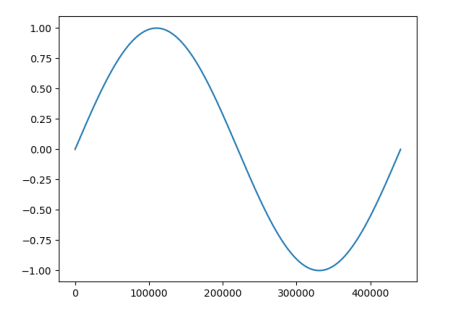 
  
Como antes, crearemos un array de NumPy para almacenar las muestras.  
En este caso será útil la función np.arange(N) para generar el array de soporte y aplicar la función np.sin para calcular el
valor de las muestras.  
Nótese que el instante t = 1 seg. corresponde al argumento 2π para la función np.sin.  




A continuación, obtener una señal de 2 Hz y 1 segundo de duración, y otra de 3 Hz y 2 segundos
de duración. Dibujar los resultados.  
Generar varias señales de 1 segundo de duración con diversas frecuencias (110 Hz, 220 Hz, . . . ), hacer una suma ponderada y reproducirlas.  
Prueba con frecuencias muy agudas y muy graves para determinar cuáles son las frecuencia mínima y máxima que puedes escuchar.  
Utiliza niveles moderados de volumen para no dañar tus oídos.  

In [ ]:
#* Ej3
dur = 1.0

freq = 1

n = int(SRATE * dur)
data = np.arange(n, dtype=float)
data = np.sin(2 * np.pi * freq * data / SRATE)

plt.figure(1)
plt.title("onda sinusoidal 1 Hz")
plt.plot(data)
plt.show()

freq = 2

data = np.arange(n, dtype=float)
data = np.sin(2 * np.pi * freq * data / SRATE)

plt.figure(2)
plt.title("onda sinusoidal 2 Hz")
plt.plot(data)
plt.show()


freq = 3
dur = 2

n = int(SRATE * dur)
data = np.arange(n, dtype=float)
data = np.sin(2 * np.pi * freq * data / SRATE)

plt.figure(3)
plt.title("onda sinusoidal reproducida (3 Hz)")
plt.plot(data)
plt.show()

freq = 220
dur = 5.0

n = int(SRATE * dur)
data = np.arange(n, dtype=float)
data = np.sin(2 * np.pi * freq * data / SRATE)

plt.figure(4)
plt.title("onda sinusoidal reproducida (220 Hz)")
plt.plot(data[:1000])
plt.show()

sd.play(data, SRATE)

#### Ejercicio 4
Vamos a generalizar el ejercicio anterior implementando una función osc(freq,dur=1,amp=1, phase=0) que devuelva una señal sinusoidal de frecuencia freq, duración dur segundos, amplitud amp y fase phase (en radianes).  
Por ejemplo, osc(2,1,1,np.pi/2) tendrá esta forma:    
  
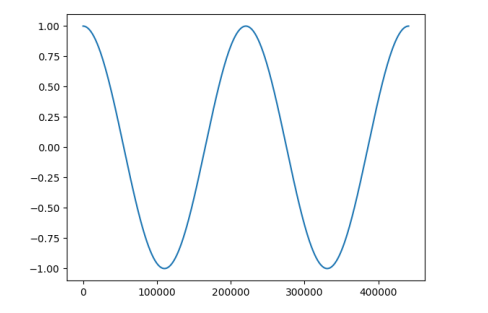    
  
Dibujar varias señales con distintos parámetros.  
Prueba con diferentes valores de fase y escucha las diferencias.  
Probar también con diferentes valores para SRATE.



In [ ]:
#* Ej4
#* SRATE = 250000
data = np.array([], dtype=float)

def osc(freq, dur=1, amp=1, phase=0):
    global data

    n = int(SRATE * dur)              # número de muestras
    data = np.arange(n, dtype=float) # índice de muestra

    data = 2 * np.pi * freq * data / SRATE + phase  # fase
    data = np.sin(data) * amp


osc(2,1,1,np.pi/2)
plt.figure(1)
plt.title("onda sinusoidal 1 (reproduccion)")
plt.plot(data)
plt.show()

osc(880,3,1,np.pi/2)
plt.figure(2)
plt.title("onda sinusoidal 2")
plt.plot(data)
plt.show()

sd.play(data,SRATE)



In [ ]:
sd.stop()

#### Ejercicio 5 (Evaluable)
Consideremos la partitura de la canción Happy Birthday:  
  
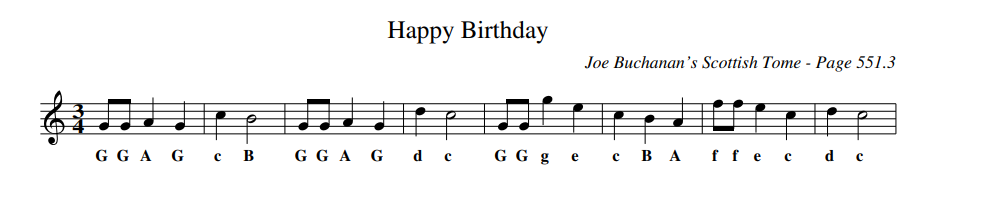  
  
Podemos hacer una representación de esta partitura mediante una lista (Python) de pares (nota,duración).  
Las notas se representan con las letras A B ...G (la, si, do,. . . , sol). Para subir una octava se utilizan las minúsculas a b ...g1.   
La duración se representa con un número que indica las unidades de tiempo (la unidad se fijará en el propio programa, por ejemplo 1 segundo)  
De este modo, la partitura anterior quedaría:  
[(G,0.5),(G,0.5),(A,1),(G,1),(c,1),(B,2),. . . ]  
La tabla de frecuencias (para una octava) es la siguiente: 

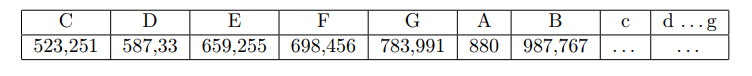  

Recordemos también que dada la frecuencia de una nota, la de la octava superior se obtiene duplicando dicha frecuencia. La de la octava inferior, dividiendo entre 2.  De este modo podemos calcular la frecuencia de cualquier nota.  
Implementar un programa para reproducir la partitura anterior utilizando el oscilador que acabamos
de ver. Puede utilizarse un pequeño silencio al final de cada nota para diferenciar bien las notas.


In [ ]:
data = []

def chainosc(freq, dur=1.0, amp=1, phase=0):
    global data

    n = int(SRATE * dur)
    datal = np.arange(n, dtype=float)

    datal = amp * np.sin(2 * np.pi * freq * datal / SRATE + phase)

    data = np.concatenate((data, datal))


freqs = {'C': 523.251, 'D' : 587.33, 'E' : 659.255, 'F' : 698.456, 'G' : 783.991, 'A': 880.0, 'B' : 987.767,
         'c' : 523.251/2, 'd' : 587.33/2, 'e' : 659.255/2, 'f' : 698.456/2, 'g' : 783.991/2, 'a' : 880.0/2, 'b': 987.767/2, ' ' : 0}

happyB = [('G', 0.5), (' ', 0.01), ('G', 0.5),(' ', 0.01), ('A', 1.0),(' ', 0.01), ('G', 1.0),(' ', 0.01), ('c', 1.0),(' ', 0.01), ('B', 2.0),(' ', 0.01), ('G', 0.5),
          (' ', 0.01), ('G', 0.5),(' ', 0.01), ('A', 1.0),(' ', 0.01), ('G', 1.0),(' ', 0.01), ('d',1.0),(' ', 0.01),('c', 2.0),(' ', 0.01), ('G', 0.5),(' ', 0.01), 
          ('G', 0.5),(' ', 0.01), ('g', 1.0),(' ', 0.01), ('e', 1.0),(' ', 0.01), ('c',1.0),(' ', 0.01), ('B',1.0),(' ', 0.01),('A',1.0),(' ', 0.01), ('f',0.5),
          (' ', 0.01), ('f',0.5),(' ', 0.01), ('e',1.0), (' ', 0.01),('c',1.0),(' ', 0.01), ('d',1.0),(' ', 0.01), ('c',2.0)]

for t in happyB:
    chainosc(freqs[t[0]],t[1])
    sd.play(data,SRATE)

plt.figure(1)
plt.title("onda sinusoidal Happy Birthday")
plt.plot(data)
plt.show()

In [ ]:
sd.stop()

#### Ejercicio 6  
Utilizando los osciladores anteriores implementar una función harmOsc(f,amps, dur, amp) para simular un nota con sus armónicos (f, 2f, 3f, . . . , fn).  
La función recibirá como parámetros la frecuencia fundamental f (o primer armónico), una lista de amplitudes de los armónicos amps=[a1,a2...,an],
la duración de la nota dur y la amplitud de la nota amp.  
El sonido resultante se calcula como suma de las señales sinusoidales de frecuencias f, 2f, 3f, . . . , fn y amplitudes a1,...,an (que se calcularán
con la función osc anterior).  
Generar algunas notas con esta función con distintas configuraciones de frecuencias/amplitudesy reproducirlas.  
¿Puedes encontrar combinaciones de frecuencias y amplitudes que aproximen el sonido de algún instrumento real?  
En ese caso, en la entrega detalla las configuraciones encontradas y los instrumentos que aproximan.


In [ ]:
def osc(freq, dur=1.0, amp=1.0, phase=0.0):
    n = int(SRATE * dur)
    t = np.arange(n, dtype=float)
    return amp * np.sin(2 * np.pi * freq * t / SRATE + phase)

def harmOsc(f, amps, dur=1.0, amp=1.0):
    """
    f    : frecuencia fundamental
    amps : lista de amplitudes [a1, a2, ..., an]
    dur  : duración en segundos
    amp  : amplitud global
    """

    n = int(SRATE * dur)
    data = np.zeros(n, dtype=float)

    for i, ai in enumerate(amps):
        freq = f * (i + 1)          # f, 2f, 3f, ...
        data += osc(freq, dur, ai)

    return amp * data


amps_flauta = [1.0, 0.2, 0.05]

data = harmOsc(440, amps_flauta, dur=2.0, amp=0.8)
sd.play(data, SRATE)
sd.wait()

amps_cuerda = [1.0, 0.8, 0.6, 0.4, 0.2]

data = harmOsc(220, amps_cuerda, dur=2.5, amp=0.7)
sd.play(data, SRATE)
sd.wait()

amps_trompeta = [1.0, 0.9, 0.7, 0.6, 0.5, 0.3]

data = harmOsc(440, amps_trompeta, dur=1.5, amp=0.6)
sd.play(data, SRATE)
sd.wait()

amps_organo = [1, 1, 1, 1]

data = harmOsc(110, amps_organo, dur=3.0, amp=0.4)
sd.play(data, SRATE)
sd.wait()



#### Ejercicio 7 (Evaluable)
Implementar una función modulator(signal,freq) que multiplique la señal signal
por otra que hace el papel de moduladora.  
Esta moduladora será un oscilador de frecuencia freq y con valores en el intervalo [0,1] (no en [-1,1] como es habitual).  
Es decir, sube y baja el volumen de la señal entre 0 y 1.  
Utilizar esta función para modular un fragmento de ruido y señales sinusoidales de distintas frecuencias.  
Prueba con distintas frecuencias de modulación. Dibujar los resultados y reproducirlos con sounddevice.  
¿Qué ocurre si dejamos que el modulador oscile en el intervalo [-1,1]?  

In [ ]:
def osc(freq, dur=1.0, amp=1.0, phase=0.0):
    n = int(SRATE * dur)
    t = np.arange(n, dtype=float)
    return amp * np.sin(2 * np.pi * freq * t / SRATE + phase)

def modulator(signal, freq):
    data = np.zeros(len(signal))
    data = (1 + np.sin(2 * np.pi * freq * data/SRATE))/2
    #plt.plot(data[:1000])
    return data * signal
    
data = osc(880,1,1)
plt.figure(1)
plt.title("onda sinusoidal")
plt.plot(data[:1000])
sd.play(data)
sd.wait()

data = modulator(osc(880,1,1),4)

plt.plot(data[:1000])
plt.show()
sd.play(data)
sd.wait()


data = osc(6,3,1,np.pi/2)
plt.figure(1)
plt.title("onda sinusoidal")
plt.plot(data)
sd.play(data)
sd.wait()

data = modulator(osc(6,3,1,np.pi/2),0.5)

plt.plot(data)
plt.show()
sd.play(data)
sd.wait()
